In [2]:
#problem 2b
import numpy as np
import matplotlib.pyplot as plt

#given constants
a = 0.04
b = 0.16
K = 0.1

#states 1,2,3,4,5
n_states = 5

#transition matrix P
P = np.zeros((n_states, n_states))

for n in range(1, n_states + 1):
    p_n = K * np.exp(a * n)          #p(n, n+1)
    q_n = K * np.exp(b * (n - 1))    #p(n, n-1)

    i = n - 1  #python index

    if n == 1:
        #from state 1, only stay or go to 2
        P[i, i+1] = p_n
        P[i, i] = 1 - p_n
    elif n == n_states:
        #from state 5, only stay or go to 4
        P[i, i-1] = q_n
        P[i, i] = 1 - q_n
    else:
        #interior states
        P[i, i+1] = p_n
        P[i, i-1] = q_n
        P[i, i] = 1 - p_n - q_n

print("Transition matrix P:")
print(P)

#find eigenvalues/eigenvectors of P^T
eigenvalues, eigenvectors = np.linalg.eig(P.T)

#find the eigenvector corresponding to eigenvalue 1
idx = np.argmin(np.abs(eigenvalues - 1))
pi = np.real(eigenvectors[:, idx])

#normalize so entries sum to 1
pi = pi / np.sum(pi)

print("\nStationary distribution:")
print(pi)

Transition matrix P:
[[0.89591892 0.10408108 0.         0.         0.        ]
 [0.11735109 0.77432021 0.10832871 0.         0.        ]
 [0.         0.13771278 0.74953754 0.11274969 0.        ]
 [0.         0.         0.16160744 0.72104147 0.11735109]
 [0.         0.         0.         0.18964809 0.81035191]]

Stationary distribution:
[0.29651214 0.26298267 0.2068695  0.14432795 0.08930774]



Empirical fraction of time in each state from simulation:
[0.297472 0.263308 0.207366 0.143766 0.088088]


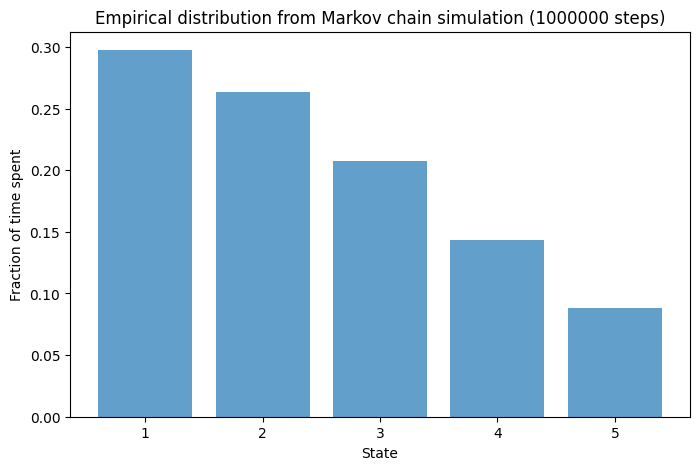

In [4]:
#problem 2c

n_steps = 10**6
states = [1,2,3,4,5]

#simulate markov chain
chain = np.zeros(n_steps, dtype=int)

#initial state = 1
chain[0] = 0

for t in range(1, n_steps):
    current_state = chain[t - 1]
    chain[t] = np.random.choice(n_states, p=P[current_state])

#count time spent in each state
counts = np.bincount(chain, minlength=n_states)
empirical = counts / n_steps

print("\nEmpirical fraction of time in each state from simulation:")
print(empirical)

#histogram
plt.figure(figsize=(8, 5))
plt.bar(states, empirical, alpha=0.7)
plt.xlabel("State")
plt.ylabel("Fraction of time spent")
plt.title(f"Empirical distribution from Markov chain simulation ({n_steps} steps)")
plt.xticks(states)
plt.show()


Theoretical stationary distribution from part (a):
[0.29651214 0.26298267 0.2068695  0.14432795 0.08930774]

Stationary distribution from eigenvector method (part b):
[0.29651214 0.26298267 0.2068695  0.14432795 0.08930774]


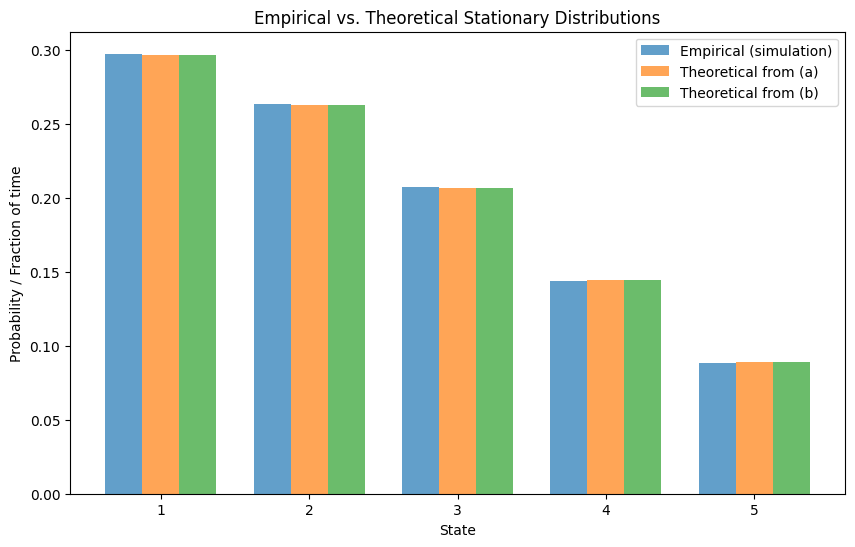

In [5]:
#problem 2d

#stationary dist from detailed balance
states = np.arange(1, n_states + 1)
pi_a = np.exp((a - b) * (states - 1) * states / 2)
pi_a = pi_a / np.sum(pi_a)

print("\nTheoretical stationary distribution from part (a):")
print(pi_a)

#stationary dist from eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(P.T)
idx = np.argmin(np.abs(eigenvalues - 1))
pi_b = np.real(eigenvectors[:, idx])

if np.sum(pi_b) < 0:
    pi_b = -pi_b

pi_b = pi_b / np.sum(pi_b)

print("\nStationary distribution from eigenvector method (part b):")
print(pi_b)

#compare detailed balance, eigenvector, and simulated histograms
width = 0.25

plt.figure(figsize=(10, 6))
plt.bar(states - width, empirical, width=width, label="Empirical (simulation)", alpha=0.7)
plt.bar(states, pi_a, width=width, label="Theoretical from (a)", alpha=0.7)
plt.bar(states + width, pi_b, width=width, label="Theoretical from (b)", alpha=0.7)

plt.xlabel("State")
plt.ylabel("Probability / Fraction of time")
plt.title("Empirical vs. Theoretical Stationary Distributions")
plt.xticks(states)
plt.legend()
plt.show()